In [10]:
%pip install antropy


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
import os
import warnings
import antropy as ant
import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd

from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from scipy.stats import pearsonr
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.feature_selection import RFE
from sklearn.metrics import (
    ConfusionMatrixDisplay, classification_report, confusion_matrix,
    f1_score, roc_auc_score, roc_curve
)
from sklearn.model_selection import (
    KFold, LeaveOneOut, RandomizedSearchCV,
    StratifiedKFold, cross_val_predict, cross_val_score
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings('ignore')

### Merging tables

In [12]:
df_demo = pd.read_csv('table/Demographics.csv')
df_bpi = pd.read_csv('table/BPI Answers.csv')
df_paindetect = pd.read_csv('table/PainDetect Answers.csv')

# Setting the ID columns to the same type
df_demo['ID'] = df_demo['ID'].astype(str)
df_bpi['ID'] = df_bpi['ID'].astype(str)
df_paindetect['ID'] = df_paindetect['ID'].astype(str)

# Merging the tables by ID
df_complete = pd.merge(df_demo, df_bpi, on='ID', how='inner')
df_complete = pd.merge(df_complete, df_paindetect, on='ID', how='inner')

df_complete = df_complete.dropna(subset=['Actual Pain'])

## Tabela de Resultados

In [13]:
csv_filename = 'eeg_ablation_results_ec.csv'

current_condition = 'Eyes Closed'
current_category = 'Somente Hjorth'
classifier_name = 'Linear SVM'

pasta_saida = 'features_extraidas_ec'
nome_arquivo_saida = 'features_hjorth.csv' 

if os.path.exists(csv_filename):
    df_results = pd.read_csv(csv_filename)
    print(f"Tabela já existe. Registros atuais: {len(df_results)}")
else:
    columns = [
        'Feature_Category', 
        'Classifier', 
        'Condition', 
        'Num_Features', 
        'Accuracy', 
        'AUC_ROC', 
        'F1_Score'
    ]
    df_results = pd.DataFrame(columns=columns)
    print("Tabela criada com sucesso.")

Tabela já existe. Registros atuais: 27


In [14]:
X_features = []
y_labels = []
feature_names = []
patient_ids = []
eeg_folder = './cleaned_ec'

target_channels = ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T7', 'T8', 'P7', 'P8', 'Fz', 'Cz', 'Pz']

### Extração das Features

In [15]:
for index, row in df_complete.iterrows():
    patient_id = int(float(row['ID'])) 
    pain_score = float(row['Actual Pain']) 
    
    path = os.path.join(eeg_folder, f"ID{patient_id}_preproc_ec-epo.fif")
    
    if os.path.exists(path):
        try:
            epochs = mne.read_epochs(path, preload=True, verbose=False)
            all_channels = epochs.ch_names
            
            epochs_data = epochs.get_data() # Formato: (n_epochs, n_channels, n_times)
            
            patient_features = []
            temp_names = [] 
            
            for channel in target_channels:
                if channel in all_channels:
                    i = all_channels.index(channel)
                    channel_epochs = epochs_data[:, i, :] # Isola o canal (n_epochs, n_times)
                    
                    # Activity
                    activity_epochs = np.var(channel_epochs, axis=1)
                    activity = np.mean(activity_epochs)
                    
                    # Mobility e Complexity
                    mobility_epochs, complexity_epochs = ant.hjorth_params(channel_epochs, axis=1)
                    mobility = np.mean(mobility_epochs)
                    complexity = np.mean(complexity_epochs)
                    
                    patient_features.extend([activity, mobility, complexity])
                    
                    if not feature_names: 
                        temp_names.extend([
                            f"Hjorth_Activity_{channel}", 
                            f"Hjorth_Mobility_{channel}", 
                            f"Hjorth_Complexity_{channel}"
                        ])
                else:
                    # Preenchimento em caso de canal ausente
                    patient_features.extend([np.nan] * 3)
                    if not feature_names:
                        temp_names.extend([
                            f"Hjorth_Activity_{channel}", 
                            f"Hjorth_Mobility_{channel}", 
                            f"Hjorth_Complexity_{channel}"
                        ])

            if not feature_names: 
                feature_names = temp_names
            
            X_features.append(patient_features)
            y_labels.append(pain_score)
            patient_ids.append(patient_id)
            print(f"Processamento do paciente {patient_id} finalizado.")
            
        except Exception as e:
            print(f"Falha no paciente {patient_id}: {e}")

X = np.array(X_features)
y = np.array(y_labels)

# Remove colunas que contenham apenas valores NaN (canais faltando em todos os pacientes)
valid_columns = ~np.isnan(X).all(axis=0)
X = X[:, valid_columns]
feature_names = np.array(feature_names)[valid_columns]

print("\n - EXTRAÇÃO CONCLUÍDA - ")
print(f"Formato Final da Matriz (X): {X.shape}")
print(f"Total de Biomarcadores Válidos: {len(feature_names)}")

# DataFrame com as features
df_features = pd.DataFrame(X, columns=feature_names)
df_features['patient_id'] = patient_ids
df_features['pain_score'] = y

os.makedirs(pasta_saida, exist_ok=True)
caminho_arquivo_saida = os.path.join(pasta_saida, nome_arquivo_saida)
df_features.to_csv(caminho_arquivo_saida, index=False)

Processamento do paciente 0 finalizado.
Processamento do paciente 1 finalizado.
Processamento do paciente 2 finalizado.
Processamento do paciente 3 finalizado.
Processamento do paciente 4 finalizado.
Processamento do paciente 5 finalizado.
Processamento do paciente 6 finalizado.
Processamento do paciente 7 finalizado.
Processamento do paciente 8 finalizado.
Processamento do paciente 9 finalizado.
Processamento do paciente 10 finalizado.
Processamento do paciente 11 finalizado.
Processamento do paciente 13 finalizado.
Processamento do paciente 15 finalizado.
Processamento do paciente 16 finalizado.
Processamento do paciente 18 finalizado.
Processamento do paciente 19 finalizado.
Processamento do paciente 20 finalizado.
Processamento do paciente 21 finalizado.
Processamento do paciente 22 finalizado.
Processamento do paciente 23 finalizado.
Processamento do paciente 24 finalizado.
Processamento do paciente 25 finalizado.
Processamento do paciente 26 finalizado.
Processamento do paciente 

### Treinamento SVM (LOO)


Avaliando Linear SVM (Somente Hjorth) — class_weight='balanced', LOO + RandomizedSearchCV
Severe Pain  (>=6): 19
Mild/Mod Pain (<6): 16

Executando LOO Nested CV...

CLASSIFICATION PERFORMANCE (LOO NESTED CV)
LOO Accuracy: 34.3%
LOO AUC-ROC: 0.395

Melhores hiperparâmetros: {'svm_final__C': 1.0}
-------------------------------------------------------

TOP 5 BIOMARCADORES (Linear SVM):
  1. Hjorth_Mobility_F7: 6.8% de importância
  2. Hjorth_Mobility_F8: 5.0% de importância
  3. Hjorth_Mobility_P8: 4.3% de importância
  4. Hjorth_Complexity_Fz: 4.1% de importância
  5. Hjorth_Activity_C3: 4.0% de importância


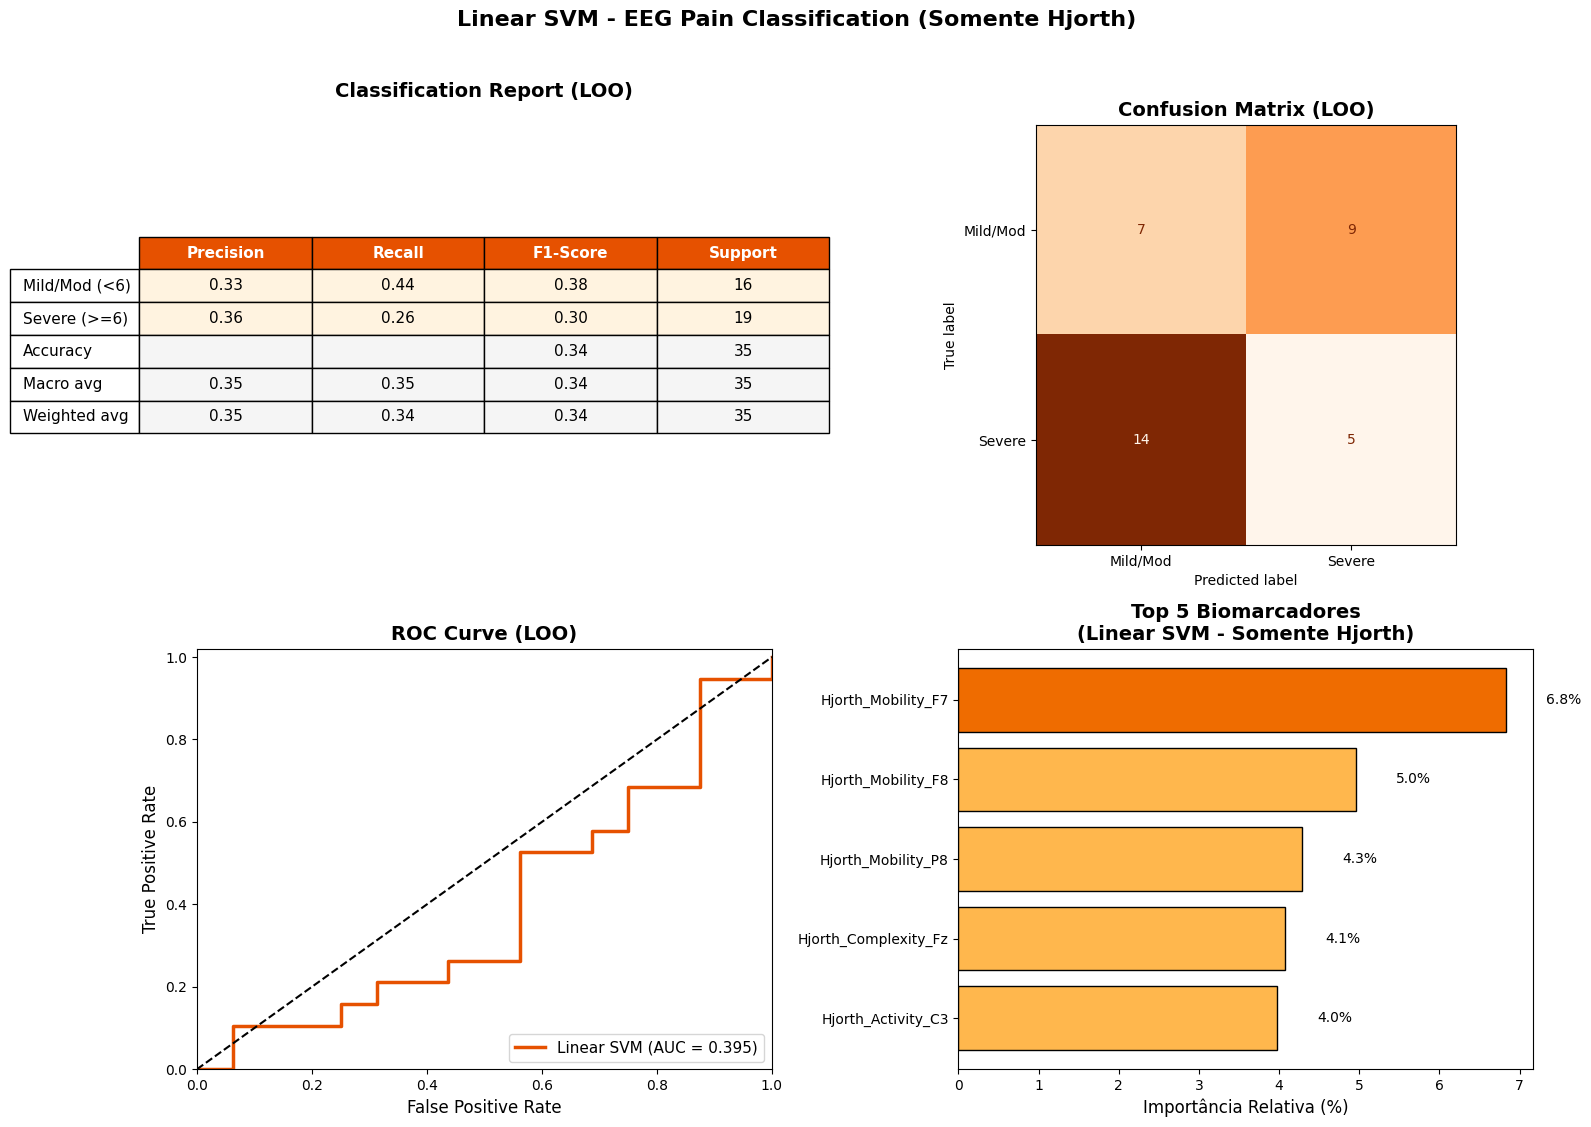


Gráfico salvo como: images\04_svm_hjorth_ec_results.png
Resultados atualizados no arquivo 'eeg_ablation_results_ec.csv'.


In [16]:
if X.shape[0] > 0:
    print('\n' + '=' * 60)
    print(f"Avaliando {classifier_name} ({current_category}) — class_weight='balanced', LOO + RandomizedSearchCV")
    print('=' * 60)

    valid_mask = [not ('M1' in n or 'M2' in n) for n in feature_names]
    X_filtered = X[:, valid_mask]
    feature_names_filt = np.array(feature_names)[valid_mask]

    y_class = np.where(y >= 6, 1, 0)
    print(f"Severe Pain  (>=6): {sum(y_class==1)}")
    print(f"Mild/Mod Pain (<6): {sum(y_class==0)}\n")

    num_top_features = 5 # Número de features para exibir no gráfico de barras

    # Pipeline base com SVM Linear
    base_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('svm_final', SVC(
            kernel='linear',
            random_state=42,
            class_weight='balanced'
        ))
    ])

    # Hiperparâmetros
    param_dist = {
        'svm_final__C': [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0],
    }

    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    outer_cv = LeaveOneOut()

    search = RandomizedSearchCV(
        base_pipeline, param_dist,
        n_iter=8, cv=inner_cv, scoring='roc_auc',
        random_state=42, n_jobs=-1, refit=True
    )

    print("Executando LOO Nested CV...")
    scores_acc = cross_val_score(search, X_filtered, y_class, cv=outer_cv, scoring='accuracy')
    
    y_score = cross_val_predict(search, X_filtered, y_class, cv=outer_cv, method='decision_function')
    y_pred = cross_val_predict(search, X_filtered, y_class, cv=outer_cv)
    auc_loo = roc_auc_score(y_class, y_score)
    acc_loo = scores_acc.mean()

    print("\nCLASSIFICATION PERFORMANCE (LOO NESTED CV)")
    print(f"LOO Accuracy: {acc_loo*100:.1f}%")
    print(f"LOO AUC-ROC: {auc_loo:.3f}")

    # Gerar o dict do classification report
    report = classification_report(y_class, y_pred,
                                   target_names=['Mild/Mod (<6)', 'Severe (>=6)'],
                                   output_dict=True, zero_division=0)

    # Treinar no dataset completo para revelar a importância dos biomarcadores
    search.fit(X_filtered, y_class)
    print(f"\nMelhores hiperparâmetros: {search.best_params_}")
    
    # Extração de Importância das Features
    importances = np.abs(search.best_estimator_.named_steps['svm_final'].coef_[0])
    importances_pct = importances / importances.sum() * 100
    ranking = np.argsort(importances_pct)[::-1]
    
    print('-' * 55)
    print(f"\nTOP {num_top_features} BIOMARCADORES ({classifier_name}):")
    for i, idx in enumerate(ranking[:num_top_features], 1):
        print(f"  {i}. {feature_names_filt[idx]}: {importances_pct[idx]:.1f}% de importância")

    # (2x2 Grid)
    fig, axes = plt.subplots(2, 2, figsize=(16, 11))
    
    ax_tbl, ax_cm = axes[0, 0], axes[0, 1]
    ax_roc, ax_feat = axes[1, 0], axes[1, 1]

    # Tabela do Classification Report
    row_labels = ['Mild/Mod (<6)', 'Severe (>=6)', 'Accuracy', 'Macro avg', 'Weighted avg']
    col_labels = ['Precision', 'Recall', 'F1-Score', 'Support']
    keys = ['Mild/Mod (<6)', 'Severe (>=6)', 'accuracy', 'macro avg', 'weighted avg']

    table_data = []
    for k in keys:
        if k == 'accuracy':
            n_total = int(report['macro avg']['support'])
            table_data.append(['', '', f"{report['accuracy']:.2f}", str(n_total)])
        else:
            r = report[k]
            table_data.append([
                f"{r['precision']:.2f}" if 'precision' in r else '',
                f"{r['recall']:.2f}" if 'recall' in r else '',
                f"{r['f1-score']:.2f}",
                str(int(r['support']))
            ])

    ax_tbl.axis('off')
    tbl = ax_tbl.table(
        cellText=table_data,
        rowLabels=row_labels,
        colLabels=col_labels,
        cellLoc='center',
        loc='center'
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(11)
    tbl.scale(1.2, 1.8)

    for j in range(len(col_labels)):
        tbl[0, j].set_facecolor('#e65100')
        tbl[0, j].set_text_props(color='white', fontweight='bold')
    for i in range(1, 3):
        for j in range(len(col_labels)):
            tbl[i, j].set_facecolor('#fff3e0')
    for i in range(3, 6):
        for j in range(len(col_labels)):
            tbl[i, j].set_facecolor('#f5f5f5') 

    ax_tbl.set_title('Classification Report (LOO)', fontsize=14, fontweight='bold', pad=20)

    # Matriz de Confusão
    cm = confusion_matrix(y_class, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Mild/Mod', 'Severe'])
    disp.plot(ax=ax_cm, colorbar=False, cmap='Oranges')
    ax_cm.set_title('Confusion Matrix (LOO)', fontsize=14, fontweight='bold')

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_class, y_score)
    ax_roc.plot(fpr, tpr, color='#e65100', lw=2.5, label=f'{classifier_name} (AUC = {auc_loo:.3f})')
    ax_roc.plot([0, 1], [0, 1], 'k--', lw=1.5)
    ax_roc.set_xlim([0, 1]); ax_roc.set_ylim([0, 1.02])
    ax_roc.set_xlabel('False Positive Rate', fontsize=12)
    ax_roc.set_ylabel('True Positive Rate', fontsize=12)
    ax_roc.set_title('ROC Curve (LOO)', fontsize=14, fontweight='bold')
    ax_roc.legend(loc='lower right', fontsize=11)

    # Top Features
    top_indices = ranking[:num_top_features]
    bios_ordered  = feature_names_filt[top_indices]
    scores_ordered = importances_pct[top_indices]
    
    colors = ['#ef6c00' if s == scores_ordered.max() else '#ffb74d' for s in scores_ordered]
    bars = ax_feat.barh(range(len(bios_ordered)), scores_ordered[::-1], color=colors[::-1], edgecolor='black')
    
    ax_feat.set_yticks(range(len(bios_ordered)))
    ax_feat.set_yticklabels(bios_ordered[::-1], fontsize=10)
    ax_feat.set_xlabel('Importância Relativa (%)', fontsize=12)
    ax_feat.set_title(f'Top {num_top_features} Biomarcadores\n({classifier_name} - {current_category})', fontsize=14, fontweight='bold')
    
    for bar, val in zip(bars, scores_ordered[::-1]):
        ax_feat.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                     f'{val:.1f}%', va='center', fontsize=10)

    plt.suptitle(f'{classifier_name} - EEG Pain Classification ({current_category})', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()

    save_folder = 'images'
    os.makedirs(save_folder, exist_ok=True)
    save_path = os.path.join(save_folder, '04_svm_hjorth_ec_results.png')
    
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"\nGráfico salvo como: {save_path}")

    new_result = pd.DataFrame([{
        'Feature_Category': current_category,
        'Classifier': classifier_name,
        'Condition': current_condition,
        'Num_Features': X_filtered.shape[1],
        'Accuracy': round(acc_loo, 4),
        'AUC_ROC': round(auc_loo, 4),
        'F1_Score': round(f1_score(y_class, y_pred), 4)
    }])
    
    df_results = pd.concat([df_results, new_result], ignore_index=True)
    df_results.to_csv(csv_filename, index=False)
    print(f"Resultados atualizados no arquivo '{csv_filename}'.")

else:
    print("Nenhum paciente processado.")


Avaliando Multi-SVM Hierárquico (Somente Hjorth) - OverSampling + RFE + LOO
Sem Dor (0): 2 pacientes
Leve (1-3): 8 pacientes
Média (4-5): 6 pacientes
Alta (6-7): 11 pacientes
Intolerável (8-10): 8 pacientes


Executando LOO Nested CV...

CLASSIFICATION PERFORMANCE (LOO NESTED CV)
LOO Accuracy: 37.1%
LOO AUC-ROC (Weighted): 0.592
-------------------------------------------------------

TOP 5 BIOMARCADORES (Linear SVM RFE):
  1. Hjorth_Mobility_P4: 29.2% de importância
  2. Hjorth_Mobility_C4: 26.3% de importância
  3. Hjorth_Activity_O1: 24.8% de importância
  4. Hjorth_Complexity_F7: 13.6% de importância
  5. Hjorth_Complexity_P4: 6.1% de importância


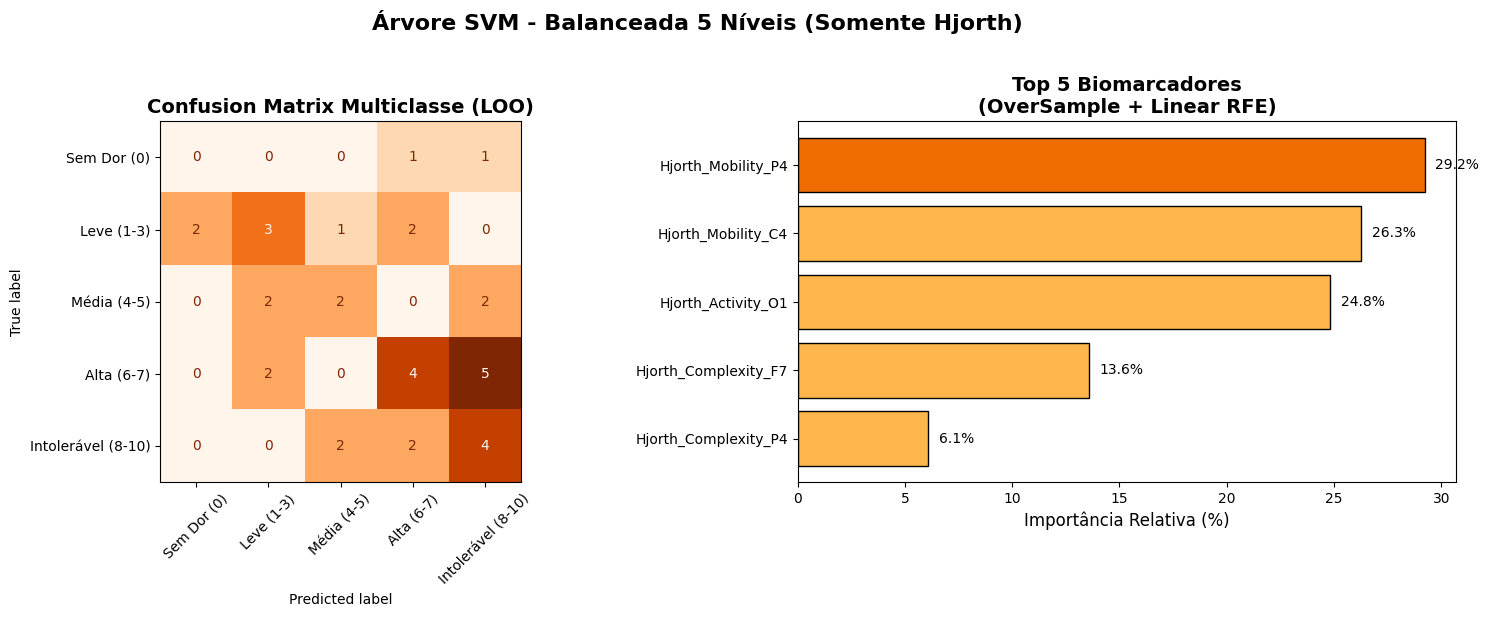


Gráfico salvo como: images\04_hierarchical_svm_hjorth_results.png

Resultados atualizados no arquivo 'eeg_ablation_results_ec.csv'.


In [17]:
# CLASSE DO MODELO: Árvore de Decisão Hierárquica (Multi-SVM)
class HierarchicalPainSVM(BaseEstimator, ClassifierMixin):
    def __init__(self, C=1.0, gamma='scale'):
        self.C = C
        self.gamma = gamma
        self.node1 = SVC(kernel='rbf', C=self.C, gamma=self.gamma, class_weight='balanced', probability=True, random_state=42)
        self.node2 = SVC(kernel='rbf', C=self.C, gamma=self.gamma, class_weight='balanced', probability=True, random_state=42)
        self.node3 = SVC(kernel='rbf', C=self.C, gamma=self.gamma, class_weight='balanced', probability=True, random_state=42)
        self.node4 = SVC(kernel='rbf', C=self.C, gamma=self.gamma, class_weight='balanced', probability=True, random_state=42)

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        y = np.array(y)
        
        y1 = np.where(y == 0, 0, 1)
        self.node1.fit(X, y1)
        
        mask2 = (y != 0)
        if np.any(mask2):
            y2 = np.where(y[mask2] == 4, 1, 0)
            self.node2.fit(X[mask2], y2)
            
        mask3 = (y != 0) & (y != 4)
        if np.any(mask3):
            y3 = np.where(y[mask3] == 3, 1, 0)
            self.node3.fit(X[mask3], y3)
            
        mask4 = (y == 1) | (y == 2)
        if np.any(mask4):
            y4 = np.where(y[mask4] == 2, 1, 0)
            self.node4.fit(X[mask4], y4)
            
        return self

    def predict(self, X):
        predictions = []
        for x_i in X:
            x_in = x_i.reshape(1, -1)
            if self.node1.predict(x_in)[0] == 0:
                predictions.append(0)
            elif self.node2.predict(x_in)[0] == 1:
                predictions.append(4)
            elif self.node3.predict(x_in)[0] == 1:
                predictions.append(3)
            elif self.node4.predict(x_in)[0] == 1:
                predictions.append(2)
            else:
                predictions.append(1)
        return np.array(predictions)
        
    def predict_proba(self, X):
        proba = np.zeros((X.shape[0], 5))
        for i, x_i in enumerate(X):
            pred = self.predict(x_i.reshape(1, -1))[0]
            proba[i, pred] = 1.0 
        return proba

# PIPELINE COM OVERSAMPLING + RFE + HIERARCHICAL SVM
if X.shape[0] > 0:
    print('\n' + '=' * 60)
    print(f"Avaliando Multi-SVM Hierárquico ({current_category}) - OverSampling + RFE + LOO")
    print('=' * 60)

    def map_pain_5_levels(score):
        if score == 0: return 0           
        elif score <= 3: return 1         
        elif score <= 5: return 2         
        elif score <= 7: return 3         
        else: return 4                    

    y_class_hierarchical = np.array([map_pain_5_levels(s) for s in y])
    
    classes_names = ['Sem Dor (0)', 'Leve (1-3)', 'Média (4-5)', 'Alta (6-7)', 'Intolerável (8-10)']
    for i, c_name in enumerate(classes_names):
        print(f"{c_name}: {sum(y_class_hierarchical==i)} pacientes")
    print("\n")

    valid_mask = [not ('M1' in n or 'M2' in n) for n in feature_names]
    X_filtered = X[:, valid_mask]
    feature_names_filt = np.array(feature_names)[valid_mask]

    num_k = 5 
    
    svm_rfe = SVC(kernel='linear', random_state=42, class_weight='balanced')
    selector_rfe = RFE(estimator=svm_rfe, n_features_to_select=num_k, step=2)

    oversampler = RandomOverSampler(random_state=42)

    base_pipeline = ImbPipeline([
        ('scaler', StandardScaler()),
        ('oversample', oversampler),
        ('rfe', selector_rfe),
        ('hierarchical_svm', HierarchicalPainSVM())
    ])

    param_dist = {
        'hierarchical_svm__C': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0],
    }

    inner_cv = KFold(n_splits=3, shuffle=True, random_state=42) 
    outer_cv = LeaveOneOut()

    search = RandomizedSearchCV(
        base_pipeline, param_dist,
        n_iter=6, cv=inner_cv, scoring='accuracy', 
        random_state=42, n_jobs=-1, refit=True
    )

    print("Executando LOO Nested CV...")
    y_pred = cross_val_predict(search, X_filtered, y_class_hierarchical, cv=outer_cv)
    y_proba = cross_val_predict(search, X_filtered, y_class_hierarchical, cv=outer_cv, method='predict_proba')
    
    acc_loo = np.mean(y_pred == y_class_hierarchical)
    try:
        auc_loo = roc_auc_score(y_class_hierarchical, y_proba, multi_class='ovr', average='weighted')
    except ValueError:
        auc_loo = 0.0 
    f1_macro = f1_score(y_class_hierarchical, y_pred, average='macro')

    print("\nCLASSIFICATION PERFORMANCE (LOO NESTED CV)")
    print(f"LOO Accuracy: {acc_loo*100:.1f}%")
    print(f"LOO AUC-ROC (Weighted): {auc_loo:.3f}")

    search.fit(X_filtered, y_class_hierarchical)
    
    mask = search.best_estimator_.named_steps['rfe'].get_support()
    biomarkers = feature_names_filt[mask]
    coef_originais = search.best_estimator_.named_steps['rfe'].estimator_.coef_[0]
    importances = np.abs(coef_originais)
    importances_pct = importances / importances.sum() * 100
    ranking = np.argsort(importances_pct)[::-1]
    
    print('-' * 55)
    print(f"\nTOP {num_k} BIOMARCADORES (Linear SVM RFE):")
    for i, idx in enumerate(ranking, 1):
        print(f"  {i}. {biomarkers[idx]}: {importances_pct[idx]:.1f}% de importância")

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    ax_cm, ax_feat = axes[0], axes[1]

    cm = confusion_matrix(y_class_hierarchical, y_pred)
    present_classes = np.unique(np.concatenate([y_class_hierarchical, y_pred]))
    disp_labels = [classes_names[i] for i in present_classes]
    
    disp = ConfusionMatrixDisplay(cm, display_labels=disp_labels)
    disp.plot(ax=ax_cm, colorbar=False, cmap='Oranges', xticks_rotation=45)
    ax_cm.set_title('Confusion Matrix Multiclasse (LOO)', fontsize=14, fontweight='bold')

    bios_ordered  = biomarkers[ranking]
    scores_ordered = importances_pct[ranking]
    
    colors = ['#ef6c00' if s == scores_ordered.max() else '#ffb74d' for s in scores_ordered]
    bars = ax_feat.barh(range(len(bios_ordered)), scores_ordered[::-1], color=colors[::-1], edgecolor='black')
    ax_feat.set_yticks(range(len(bios_ordered)))
    ax_feat.set_yticklabels(bios_ordered[::-1], fontsize=10)
    ax_feat.set_xlabel('Importância Relativa (%)', fontsize=12)
    ax_feat.set_title(f'Top {num_k} Biomarcadores\n(OverSample + Linear RFE)', fontsize=14, fontweight='bold')
    
    for bar, val in zip(bars, scores_ordered[::-1]):
        ax_feat.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                     f'{val:.1f}%', va='center', fontsize=10)

    plt.suptitle(f'Árvore SVM - Balanceada 5 Níveis ({current_category})', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()

    save_folder = 'images'
    os.makedirs(save_folder, exist_ok=True)
    save_path = os.path.join(save_folder, '04_hierarchical_svm_hjorth_results.png') 
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"\nGráfico salvo como: {save_path}")

    if os.path.exists(csv_filename):
        df_results = pd.read_csv(csv_filename)
    else:
        df_results = pd.DataFrame()

    new_result = pd.DataFrame([{
        'Feature_Category': current_category + ' + RFE + OverSample',
        'Classifier': "Hierarchical Multi-SVM",
        'Condition': current_condition,
        'Num_Features': num_k,
        'Accuracy': round(acc_loo, 4),
        'AUC_ROC': round(auc_loo, 4),
        'F1_Score': round(f1_macro, 4)
    }])
    
    df_results = pd.concat([df_results, new_result], ignore_index=True)
    df_results.to_csv(csv_filename, index=False)
    print(f"\nResultados atualizados no arquivo '{csv_filename}'.")

else:
    print("Nenhum paciente processado.")

Extração temporal dos Top 5 Biomarcadores do Modelo
[Hjorth_Mobility_F7] Tempo mínimo de estabilidade (>90% de correlação): 185 segundos.
[Hjorth_Mobility_F8] Tempo mínimo de estabilidade (>90% de correlação): 215 segundos.
[Hjorth_Mobility_P8] Tempo mínimo de estabilidade (>90% de correlação): 20 segundos.
[Hjorth_Complexity_Fz] Tempo mínimo de estabilidade (>90% de correlação): 40 segundos.
[Hjorth_Activity_C3] Tempo mínimo de estabilidade (>90% de correlação): 20 segundos.


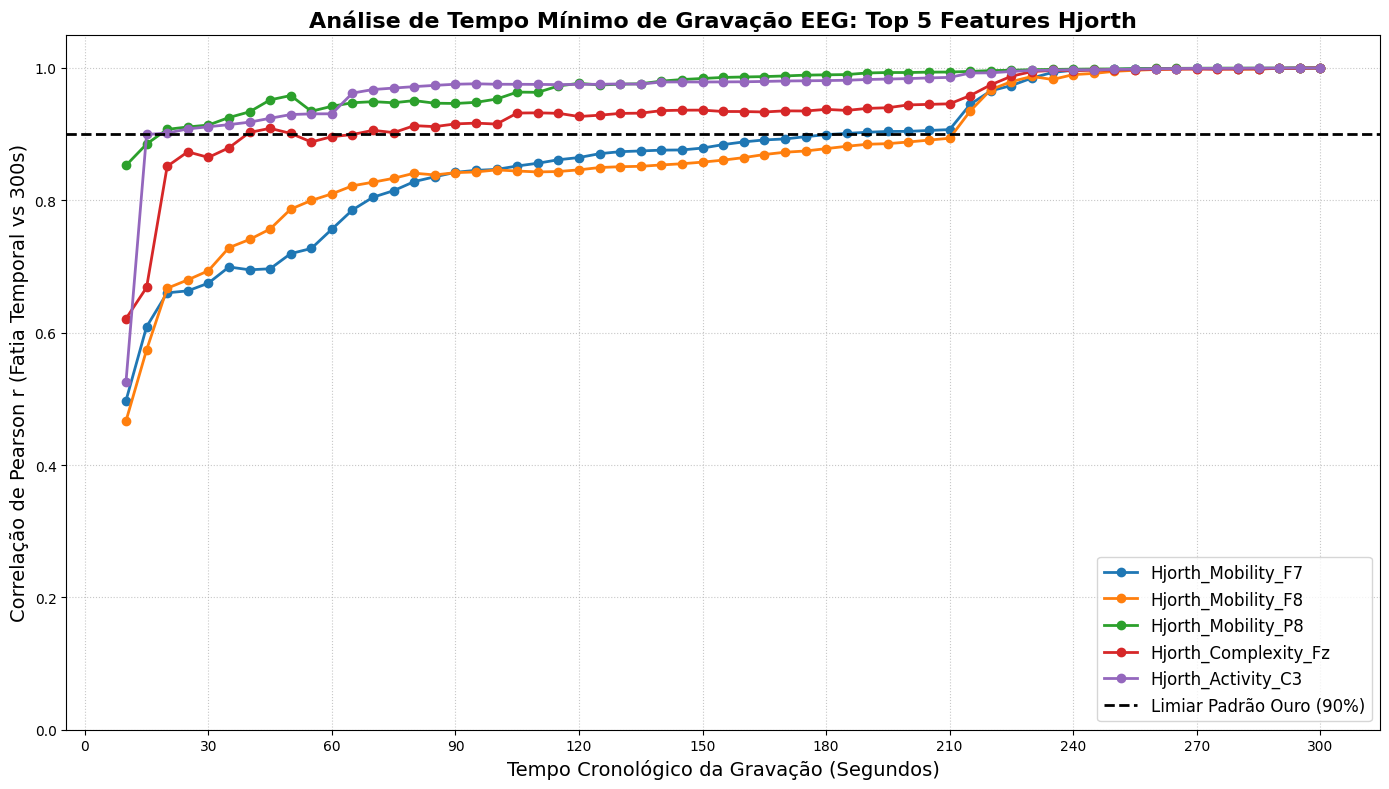

In [18]:
# Top 5 Features do Modelo Hjorth
top_features_hjorth = [
    {'name': 'Hjorth_Mobility_F7',   'channel': 'F7', 'feat_type': 'mobility'},
    {'name': 'Hjorth_Mobility_F8',   'channel': 'F8', 'feat_type': 'mobility'},
    {'name': 'Hjorth_Mobility_P8',   'channel': 'P8', 'feat_type': 'mobility'},
    {'name': 'Hjorth_Complexity_Fz', 'channel': 'Fz', 'feat_type': 'complexity'},
    {'name': 'Hjorth_Activity_C3',   'channel': 'C3', 'feat_type': 'activity'}
]

epoch_length_sec = 5
time_steps_sec = np.arange(5, 305, 5)  # Passo de 5s até 300s

def extract_specific_hjorth(channel_epochs_2d, feat_type):
    """Extrai o valor numérico de Hjorth baseado nas épocas (n_epochs, n_times) de um canal."""
    if feat_type == 'activity':
        # Variância do sinal no tempo, média pelas épocas
        return np.mean(np.var(channel_epochs_2d, axis=1))
    elif feat_type == 'mobility':
        mob, _ = ant.hjorth_params(channel_epochs_2d, axis=1)
        return np.mean(mob)
    elif feat_type == 'complexity':
        _, comp = ant.hjorth_params(channel_epochs_2d, axis=1)
        return np.mean(comp)
    return np.nan

# Dicionário para armazenar o histórico: {Nome_da_Feature: {ID_Paciente: {tempo_sec: valor, 'gold': valor}}}
history_hjorth = {feat['name']: {int(float(pid)): {} for pid in df_complete['ID']} for feat in top_features_hjorth}

print("Extração temporal dos Top 5 Biomarcadores do Modelo")

# Fatiamento Cronológico Temporal e Cálculo Iterativo
for index, row in df_complete.iterrows():
    patient_id = int(float(row['ID']))
    path = os.path.join(eeg_folder, f"ID{patient_id}_preproc_ec-epo.fif")
    
    if not os.path.exists(path):
        continue
        
    try:
        epochs = mne.read_epochs(path, preload=True, verbose=False)
        chronological_ids = epochs.events[:, 2] 
        epochs_data_gold = epochs.get_data() # (n_epochs, n_channels, n_times)
        
        # Padrão Ouro (Características da Gravação Total Limpa - 300s)
        for feat in top_features_hjorth:
            ch_name = feat['channel']
            if ch_name in epochs.ch_names:
                ch_idx = epochs.ch_names.index(ch_name)
                channel_epochs_gold = epochs_data_gold[:, ch_idx, :]
                history_hjorth[feat['name']][patient_id]['gold'] = extract_specific_hjorth(
                    channel_epochs_gold, feat['feat_type']
                )
            else:
                history_hjorth[feat['name']][patient_id]['gold'] = np.nan

        # Fatiamento Cronológico Temporal (5s até 300s)
        for t_sec in time_steps_sec:
            max_chronological_id = int(t_sec / epoch_length_sec) - 1
            valid_indices = np.where(chronological_ids <= max_chronological_id)[0]
            epochs_slice = epochs[valid_indices]
            
            if len(epochs_slice) == 0:
                for feat in top_features_hjorth:
                    history_hjorth[feat['name']][patient_id][t_sec] = np.nan
            else:
                epochs_data_t = epochs_slice.get_data()
                
                for feat in top_features_hjorth:
                    ch_name = feat['channel']
                    if ch_name in epochs.ch_names:
                        ch_idx = epochs.ch_names.index(ch_name)
                        channel_epochs_t = epochs_data_t[:, ch_idx, :]
                        history_hjorth[feat['name']][patient_id][t_sec] = extract_specific_hjorth(
                            channel_epochs_t, feat['feat_type']
                        )
                    else:
                        history_hjorth[feat['name']][patient_id][t_sec] = np.nan
                        
    except Exception as e:
        print(f"Aviso no paciente {patient_id}: {e}")

# Cálculo da Correlação de Pearson (Gráfico de Convergência)
plt.figure(figsize=(14, 8))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
threshold = 0.90

for feat, color in zip(top_features_hjorth, colors):
    feat_name = feat['name']
    correlations = []
    valid_times = []
    
    valid_patients = [pid for pid, data in history_hjorth[feat_name].items() if 'gold' in data and not np.isnan(data['gold'])]
    
    for t_sec in time_steps_sec:
        vals_t = []
        vals_gold = []
        
        for pid in valid_patients:
            val_t = history_hjorth[feat_name][pid].get(t_sec, np.nan)
            val_gold = history_hjorth[feat_name][pid]['gold']
            
            if not np.isnan(val_t) and not np.isnan(val_gold):
                vals_t.append(val_t)
                vals_gold.append(val_gold)
                
        # Calcular a estabilidade usando Pearson r (exige ao menos 10 pacientes válidos)
        if len(vals_t) > 10:
            corr, _ = pearsonr(vals_t, vals_gold)
            correlations.append(corr)
            valid_times.append(t_sec)
    
    plt.plot(valid_times, correlations, marker='o', linewidth=2, color=color, label=feat_name)
    
    # Imprimir tempo onde a feature atinge a confiabilidade do padrão ouro
    min_time = next((t for t, c in zip(valid_times, correlations) if c >= threshold), None)
    if min_time:
        print(f"[{feat_name}] Tempo mínimo de estabilidade (>90% de correlação): {min_time} segundos.")
    else:
        print(f"[{feat_name}] Não atingiu 90% de estabilidade nos primeiros {max(time_steps_sec)}s.")

plt.axhline(y=threshold, color='black', linestyle='--', linewidth=2, label='Limiar Padrão Ouro (90%)')

plt.title('Análise de Tempo Mínimo de Gravação EEG: Top 5 Features Hjorth', fontsize=16, fontweight='bold')
plt.xlabel('Tempo Cronológico da Gravação (Segundos)', fontsize=14)
plt.ylabel('Correlação de Pearson r (Fatia Temporal vs 300s)', fontsize=14)
plt.ylim(0.0, 1.05)
plt.xticks(np.arange(0, 305, 30))
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=12, loc='lower right')

plt.tight_layout()
plt.savefig(os.path.join(save_folder, '04_svm_hjorth_time_convergence.png'), dpi=300)
plt.show()